In [21]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def generateAllPosibleStartingPoints(numPoints: int, k: int):
    return np.array([i for i in range(2**numPoints) if i.bit_count() == k])

In [23]:
def variability(cluster):
    cluster = np.array(cluster)
    
    if len(cluster) == 0:
        return 0.0
        
    centroid = np.mean(cluster, axis=0)
    
    return np.sum((cluster - centroid) ** 2)

In [24]:
def dissimilarity(clusters):
    return sum(variability(c) for c in clusters)

In [25]:
def kmeans(points, k = 3):
    n = len(points)
    shape = len(points[0])
    startingIndexes = np.random.choice(n, size=k, replace=False)
    means = np.array([points[i] for i in startingIndexes])
    clustersMap = [0]*n
    prevCmap = [None]*n
    while prevCmap != clustersMap:
        prevCmap = list(clustersMap)
        for i,p in enumerate(points):
            minDist = np.inf
            for ci,mean in enumerate(means):
                d = np.linalg.norm(p-mean)
                if d < minDist:
                    minDist = d
                    clustersMap[i] = ci

        means = np.zeros((k,shape)) 
        csize = np.zeros(k)
        for (ci, p) in zip(clustersMap,points):
            means[ci] += p
            csize[ci] += 1
        for ci, mean in enumerate(means):
            if csize[ci]!=0:
                means[ci] = mean/csize[ci]
            else: # cluster no longer exists :< other way is setting it once again to randomly choose point :>
                means[ci] = np.ones(shape) * np.inf

    return clustersMap, means 

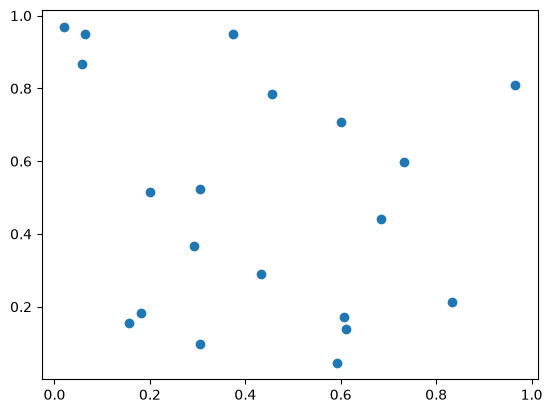

In [26]:
np.random.seed(42)
points = data = np.random.rand(20, 2)
plt.scatter(data[:,0], data[:,1])

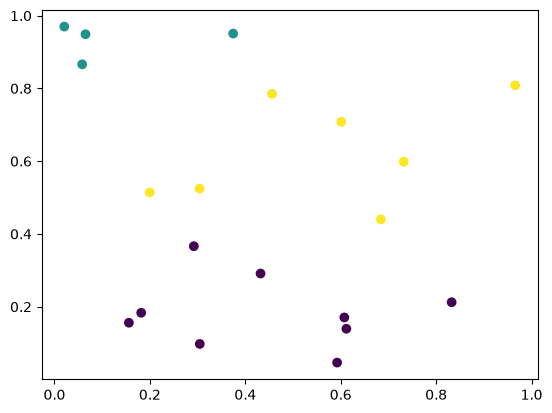

In [27]:
# probably not the best clustering
cmap, _ = kmeans(points)
plt.scatter(points[:, 0], points[:, 1], c=cmap)

In [28]:
def kmeansNP(points, k = 3):
    pts = np.array(points)
    n = pts.shape[0]
    startingIndexes = np.random.choice(n, size=k, replace=False)
    means = pts[startingIndexes].astype(float)
    clustersMap = np.zeros(n, dtype=int)
    prevCmap = - np.ones(n, dtype=int)
    while not np.array_equal(prevCmap, clustersMap):
        prevCmap = clustersMap 
    
        differences = pts[:, np.newaxis, :] - means[np.newaxis, :, :]
        distances = np.linalg.norm(differences, axis=-1)
        clustersMap = np.argmin(distances, axis=1)

        for i in range(k):
            mask = (clustersMap == i)
            if np.any(mask):
                means[i] = np.mean(pts[mask], axis=0)
            else:
                means[i] = np.inf

    return clustersMap, means

In [29]:
def betterClustering(points, n, fast = True, k=3): # n is number of iterations
    best = np.inf
    if fast:
        kmeansf = kmeansNP
    kmeansf = kmeans
    bestcmap = np.ones(len(points))
    for _ in range(n):
        cmap, _ = kmeansf(points, k)
        clusters = [[] for i in range(k)]
        for (ci, p) in zip(cmap, points):
            clusters[ci].append(p)
        d = dissimilarity(clusters)

        if d<best:
            best = d
            bestcmap = cmap
    return bestcmap

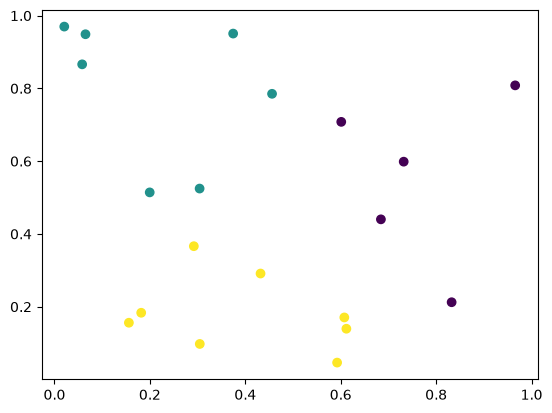

In [30]:
bcmap = betterClustering(points, 100)
plt.scatter(points[:, 0], points[:, 1], c=bcmap)

In [31]:
penguin = Image.open('image.jpg')
penguinA = np.array(penguin)
vectors = penguinA.reshape(-1, 3)

In [32]:
cmap, colors = kmeans(vectors, 5)

In [33]:
cmap, colors = kmeansNP(vectors, 5)

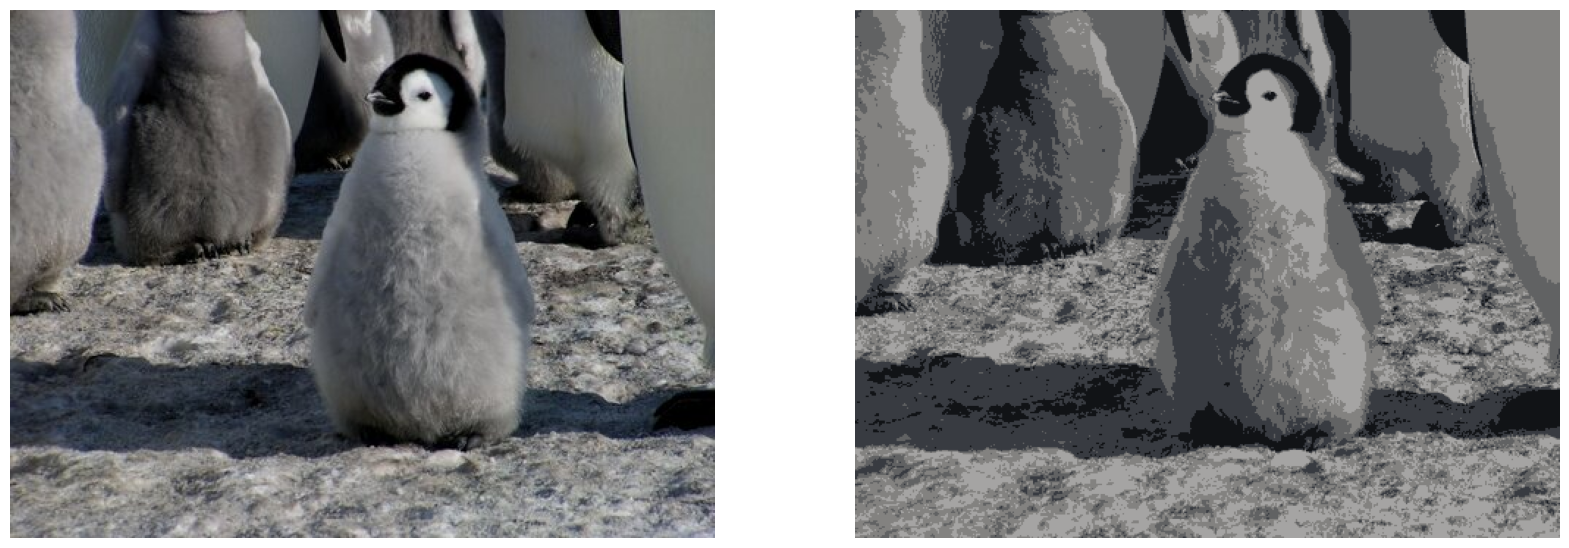

In [34]:
shape = penguinA.shape 
cmapA = np.array(cmap)
reassembledVectors = colors[cmapA]
reassembledImage = reassembledVectors.reshape(shape)
reassembledImage = reassembledImage.astype(np.uint8)
penguinAfterClustering = Image.fromarray(reassembledImage)

fig, ax = plt.subplots(1,2, figsize=[20,20])
ax[0].axis('off')
ax[1].axis('off')
ax[0].imshow(penguinA)
ax[1].imshow(penguinAfterClustering)

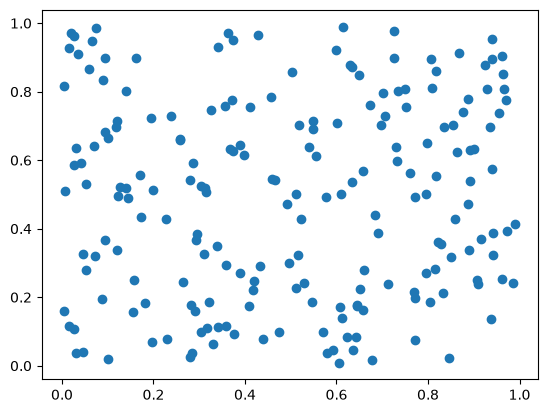

In [35]:
np.random.seed(42)
points = data = np.random.rand(200, 2)
plt.scatter(data[:,0], data[:,1])

In [36]:
dissimilarities = np.zeros(10)
for k in range(1,10):
    clustersMap, _ = kmeansNP(points,k)
    pts = np.array(points)
    clusters = [pts[clustersMap == i] for i in range(k)]
    dissimilarities[k] = dissimilarity(clusters)

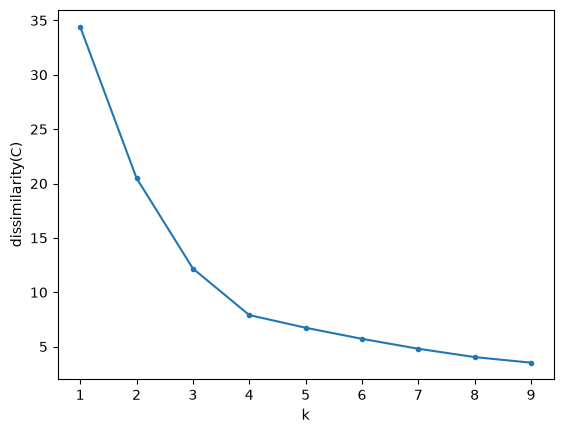

In [37]:
plt.plot(np.arange(1,10),dissimilarities[1:], marker = '.')
plt.xlabel("k")
plt.ylabel("dissimilarity(C)")
plt.show()

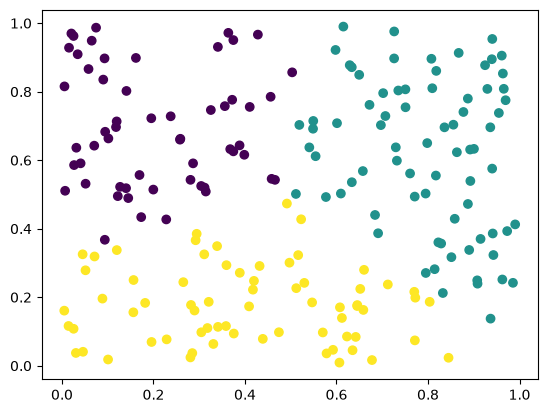

In [38]:
clustersMap, _ = kmeansNP(points,3)
plt.scatter(points[:, 0], points[:, 1], c=clustersMap)

### Afterthoughts

1. Python `for` loops are extremely slow :>. To be fair I could do this better by simply vectorizing everything, but in my defense, the code is currently written in almost pure Python, with NumPy serving merely as a quick, lazy workaround. Also it's quite intuitive.
2. I added the np version of the clustering and difference in execution time is kinda insane from 30ish seconds to 0.4s. GJ numpy.
3. Downscaling + pixel clustering + color to ascii maping -> can easily change any photo into ascii art (maybe i will do it in the future)

Lastly shoutout to Prof. John Guttag and MIT for this lecture: https://www.youtube.com/watch?v=esmzYhuFnds